# 01 — EDA (Exploratory Data Analysis) & dataset confirmation

Goal: confirm Recruit fits the brief and surface the modelling decisions before writing any
feature/model code. This notebook walks **every file** in the dataset and covers:

1. File inventory — shapes, dtypes, a peek at each of the 8 CSVs
2. **Null analysis** — missing values per column, per table
3. **Cardinality / value counts** — stores, genres, areas, day-of-week, holidays
4. Target (`visitors`) distribution — raw vs `log1p`
5. Date coverage & the **missing-day (closed-day) structure** — the key modelling decision
6. Seasonality — day-of-week and holiday effects, the Golden Week spike
7. Reservations as a **leading indicator**
8. **Correlation analysis** on a numeric daily panel

See [`../docs/01-data.md`](../docs/01-data.md) for the file structure and why Recruit was
chosen. **Run `make data` first** (needs Kaggle CLI + accepted competition rules) — the cells
below read from `data/raw/`.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Resolve repo root whether the notebook runs from notebooks/ or the repo root.
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
DATA = ROOT / "data" / "raw"

FILES = [
    "air_visit_data.csv",
    "air_reserve.csv",
    "hpg_reserve.csv",
    "air_store_info.csv",
    "hpg_store_info.csv",
    "store_id_relation.csv",
    "date_info.csv",
    "sample_submission.csv",
]

missing = [f for f in FILES if not (DATA / f).exists()]
assert not missing, (
    f"Missing {len(missing)} file(s) in {DATA}: {missing}\n"
    "Run `make data` (Kaggle CLI + accepted competition rules) to download them."
)

# Parse dates up front so every later cell gets real datetimes.
visits = pd.read_csv(DATA / "air_visit_data.csv", parse_dates=["visit_date"])
air_reserve = pd.read_csv(DATA / "air_reserve.csv", parse_dates=["visit_datetime", "reserve_datetime"])
hpg_reserve = pd.read_csv(DATA / "hpg_reserve.csv", parse_dates=["visit_datetime", "reserve_datetime"])
air_store = pd.read_csv(DATA / "air_store_info.csv")
hpg_store = pd.read_csv(DATA / "hpg_store_info.csv")
relation = pd.read_csv(DATA / "store_id_relation.csv")
dates = pd.read_csv(DATA / "date_info.csv", parse_dates=["calendar_date"])
submission = pd.read_csv(DATA / "sample_submission.csv")

tables = {
    "air_visit_data": visits,
    "air_reserve": air_reserve,
    "hpg_reserve": hpg_reserve,
    "air_store_info": air_store,
    "hpg_store_info": hpg_store,
    "store_id_relation": relation,
    "date_info": dates,
    "sample_submission": submission,
}
print(f"Loaded {len(tables)} tables from {DATA}")

Loaded 8 tables from /Users/pau/Documents/gstock/data/raw


## 1. File inventory — shape, dtypes, a peek at each table

Walk all 8 CSVs so we know exactly what we're working with.

In [4]:
# One-line summary per table, then head() of each.
summary = pd.DataFrame(
    [{"table": name, "rows": len(df), "cols": df.shape[1], "columns": ", ".join(df.columns)}
     for name, df in tables.items()]
)
display(summary)

for name, df in tables.items():
    print(f"\n===== {name}  {df.shape} =====")
    print(df.dtypes.to_string())
    display(df.head(3))

,table,rows,cols,columns
0,air_visit_data,252108,3,"air_store_id, visit_date, visitors"
1,air_reserve,92378,4,"air_store_id, visit_datetime, reserve_datetime..."
2,hpg_reserve,2000320,4,"hpg_store_id, visit_datetime, reserve_datetime..."
3,air_store_info,829,5,"air_store_id, air_genre_name, air_area_name, l..."
4,hpg_store_info,4690,5,"hpg_store_id, hpg_genre_name, hpg_area_name, l..."
5,store_id_relation,150,2,"air_store_id, hpg_store_id"
6,date_info,517,3,"calendar_date, day_of_week, holiday_flg"
7,sample_submission,32019,2,"id, visitors"



===== air_visit_data  (252108, 3) =====
air_store_id            object
visit_date      datetime64[ns]
visitors                 int64


,air_store_id,visit_date,visitors
0,air_ba937bf13d40fb24,2016-01-13,25
1,air_ba937bf13d40fb24,2016-01-14,32
2,air_ba937bf13d40fb24,2016-01-15,29



===== air_reserve  (92378, 4) =====
air_store_id                object
visit_datetime      datetime64[ns]
reserve_datetime    datetime64[ns]
reserve_visitors             int64


,air_store_id,visit_datetime,reserve_datetime,reserve_visitors
0,air_877f79706adbfb06,2016-01-01 19:00:00,2016-01-01 16:00:00,1
1,air_db4b38ebe7a7ceff,2016-01-01 19:00:00,2016-01-01 19:00:00,3
2,air_db4b38ebe7a7ceff,2016-01-01 19:00:00,2016-01-01 19:00:00,6


...

,air_store_id,hpg_store_id
0,air_63b13c56b7201bd9,hpg_4bc649e72e2a239a
1,air_a24bf50c3e90d583,hpg_c34b496d0305a809
2,air_c7f78b4f3cba33ff,hpg_cd8ae0d9bbd58ff9



===== date_info  (517, 3) =====
calendar_date    datetime64[ns]
day_of_week              object
holiday_flg               int64


,calendar_date,day_of_week,holiday_flg
0,2016-01-01,Friday,1
1,2016-01-02,Saturday,1
2,2016-01-03,Sunday,1



===== sample_submission  (32019, 2) =====
id          object
visitors     int64


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,0
1,air_00a91d42b08b08d9_2017-04-24,0
2,air_00a91d42b08b08d9_2017-04-25,0


## 2. Null analysis

Missing values per column, per table. Expectation: the visit/calendar tables are dense;
reservation/store tables may have gaps (e.g. HPG stores missing genre/area).

In [5]:
for name, df in tables.items():
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"{name:20s} no nulls")
    else:
        print(f"{name:20s} NULLS:")
        for col, n in nulls.items():
            print(f"    {col:24s} {n:>8,d}  ({n / len(df):.1%})")

# Also check for duplicate rows in the target table.
print(f"\nair_visit duplicate (store, date) rows: "
      f"{visits.duplicated(['air_store_id', 'visit_date']).sum()}")

air_visit_data       no nulls
air_reserve          no nulls
hpg_reserve          no nulls
air_store_info       no nulls
hpg_store_info       no nulls
store_id_relation    no nulls
date_info            no nulls
sample_submission    no nulls

air_visit duplicate (store, date) rows: 0


## 3. Cardinality & value counts of the key variables

How many distinct stores, how the AIR/HPG systems overlap, and the categorical breakdowns
(genre, area, day-of-week, holiday flag) we'll turn into features.

In [6]:
# Store counts and how the two systems overlap.
print("Distinct stores")
print(f"  AIR stores in visits      : {visits['air_store_id'].nunique()}")
print(f"  AIR stores in air_store   : {air_store['air_store_id'].nunique()}")
print(f"  HPG stores in hpg_store   : {hpg_store['hpg_store_id'].nunique()}")
print(f"  AIR<->HPG id pairs        : {len(relation)}  "
      f"(only these AIR stores have HPG reservation data)")

# Categorical cardinality + top values.
print("\nAIR genres:", air_store['air_genre_name'].nunique())
display(air_store['air_genre_name'].value_counts())

print("AIR areas:", air_store['air_area_name'].nunique())
display(air_store['air_area_name'].value_counts().head(10))

print("\ndate_info.day_of_week:")
display(dates['day_of_week'].value_counts())
print("date_info.holiday_flg (share of calendar days that are holidays):")
display(dates['holiday_flg'].value_counts(normalize=True).round(3))

Distinct stores
  AIR stores in visits      : 829
  AIR stores in air_store   : 829
  HPG stores in hpg_store   : 4690
  AIR<->HPG id pairs        : 150  (only these AIR stores have HPG reservation data)

AIR genres: 14


air_genre_name
Izakaya                         197
Cafe/Sweets                     181
Dining bar                      108
Italian/French                  102
Bar/Cocktail                     79
Japanese food                    63
Other                            27
Yakiniku/Korean food             23
Western food                     16
Okonomiyaki/Monja/Teppanyaki     14
Creative cuisine                 13
International cuisine             2
Asian                             2
Karaoke/Party                     2
Name: count, dtype: int64

AIR areas: 103


air_area_name
Fukuoka-ken Fukuoka-shi Daimyō                64
Tōkyō-to Shibuya-ku Shibuya                   58
Tōkyō-to Minato-ku Shibakōen                  51
Tōkyō-to Shinjuku-ku Kabukichō                39
Tōkyō-to Setagaya-ku Setagaya                 30
Tōkyō-to Chūō-ku Tsukiji                      29
Ōsaka-fu Ōsaka-shi Ōgimachi                   25
Hiroshima-ken Hiroshima-shi Kokutaijimachi    23
Tōkyō-to Meguro-ku Kamimeguro                 22
Hokkaidō Sapporo-shi Minami 3 Jōnishi         21
Name: count, dtype: int64


date_info.day_of_week:


day_of_week
Friday       74
Saturday     74
Sunday       74
Monday       74
Tuesday      74
Wednesday    74
Thursday     73
Name: count, dtype: int64

date_info.holiday_flg (share of calendar days that are holidays):


holiday_flg
0    0.932
1    0.068
Name: proportion, dtype: float64

## 4. Target distribution — `visitors`

Count data, right-skewed → motivates the `log1p` target and RMSLE metric
(see [`../docs/04-evaluation.md`](../docs/04-evaluation.md)).

count    252108.00
mean         20.97
std          16.76
min           1.00
25%           9.00
50%          17.00
75%          29.00
max         877.00
skew (raw)   : 3.31
skew (log1p) : -0.45


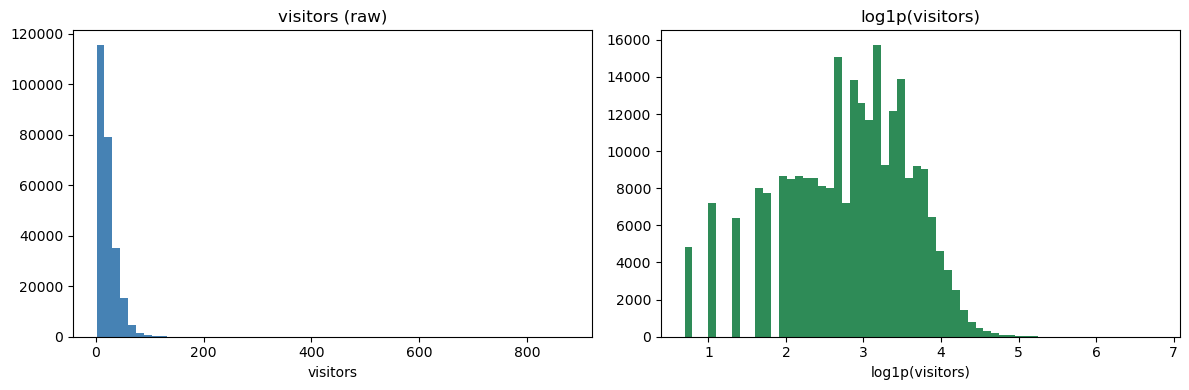

In [7]:
print(visits["visitors"].describe().round(2).to_string())
print(f"skew (raw)   : {visits['visitors'].skew():.2f}")
print(f"skew (log1p) : {np.log1p(visits['visitors']).skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(visits["visitors"], bins=60, color="steelblue")
ax[0].set_title("visitors (raw)"); ax[0].set_xlabel("visitors")
ax[1].hist(np.log1p(visits["visitors"]), bins=60, color="seagreen")
ax[1].set_title("log1p(visitors)"); ax[1].set_xlabel("log1p(visitors)")
plt.tight_layout(); plt.show()

## 5. Date coverage & the missing-day (closed-day) structure

The central modelling decision: **closed days are absent rows, not zeros**. Here we measure
how big that gap is — what fraction of each store's active span is actually present.
Competition winners (Max Halford, 8th place) resampled to a full daily index and filled `0`,
which makes time-based rolling features calendar-aligned. We quantify it before deciding
(see [`../docs/01-data.md`](../docs/01-data.md)).

In [8]:
print("Calendar span")
print(f"  visits   : {visits['visit_date'].min().date()} -> {visits['visit_date'].max().date()}")
print(f"  date_info: {dates['calendar_date'].min().date()} -> {dates['calendar_date'].max().date()}")

# The official holdout / Golden Week window.
gw = dates[(dates["calendar_date"] >= "2017-04-23") & (dates["calendar_date"] <= "2017-05-31")]
print(f"\nHoldout window 2017-04-23..2017-05-31: {len(gw)} days, "
      f"{int(gw['holiday_flg'].sum())} flagged holidays (Golden Week)")

# Per-store coverage: present days vs full active span (first..last observed).
def coverage(g):
    span = (g["visit_date"].max() - g["visit_date"].min()).days + 1
    return pd.Series({"present_days": len(g), "span_days": span, "coverage": len(g) / span})

cov = visits.groupby("air_store_id").apply(coverage, include_groups=False)
print("\nPer-store coverage (present_days / active_span):")
print(cov["coverage"].describe().round(3).to_string())
print(f"\nTotal missing (closed) day-rows across all stores' active spans: "
      f"{int((cov['span_days'] - cov['present_days']).sum()):,}")

cov["coverage"].hist(bins=40, figsize=(7, 3), color="indianred")
plt.title("Per-store calendar coverage"); plt.xlabel("coverage"); plt.show()

Calendar span
  visits   : 2016-01-01 -> 2017-04-22
  date_info: 2016-01-01 -> 2017-05-31

Holdout window 2017-04-23..2017-05-31: 39 days, 4 flagged holidays (Golden Week)


TypeError: coverage() got an unexpected keyword argument 'include_groups'

## 6. Seasonality — day-of-week, holidays, and the time series itself

Day-of-week is the dominant signal in restaurant demand; holidays shift it. The aggregate
daily curve also shows the Golden Week spike and the dataset's mid-2016 onboarding of new
stores.

Mean visitors by holiday_flg:
 holiday_flg
0    20.83
1    23.70


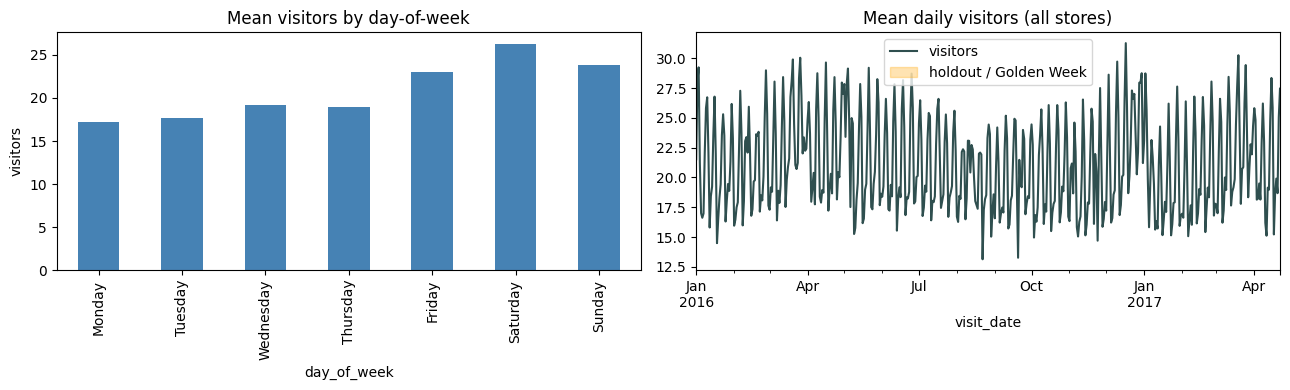

In [ ]:
# Attach calendar info (day_of_week, holiday_flg) to each visit row.
v = visits.merge(
    dates.rename(columns={"calendar_date": "visit_date"}), on="visit_date", how="left"
)

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = v.groupby("day_of_week")["visitors"].mean().reindex(dow_order)
by_hol = v.groupby("holiday_flg")["visitors"].mean()
print("Mean visitors by holiday_flg:\n", by_hol.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_dow.plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Mean visitors by day-of-week"); ax[0].set_ylabel("visitors")

daily = v.groupby("visit_date")["visitors"].mean()
daily.plot(ax=ax[1], color="darkslategray")
ax[1].axvspan(pd.Timestamp("2017-04-23"), pd.Timestamp("2017-05-31"),
              color="orange", alpha=0.3, label="holdout / Golden Week")
ax[1].set_title("Mean daily visitors (all stores)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Reservations as a leading indicator

Reservations are known *before* the visit day, so they're a legitimate (non-leaking) feature.
We aggregate both systems to `(air_store_id, visit_date)` and check how well same-day reserved
visitors track actual visitors. AIR reservations are keyed directly; HPG reservations are
joined to their AIR id via `store_id_relation`.

Visit-days with >0 reservations: 35,698 / 252,108 (14.2%)
corr(reserve_visitors, visitors) on reserved days: 0.416


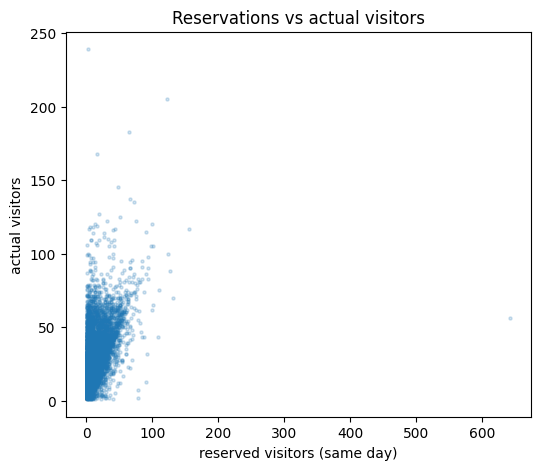

In [ ]:
def daily_reserve(df, store_col):
    """Sum reserved visitors per (air_store_id, visit_date)."""
    out = df.copy()
    out["visit_date"] = out["visit_datetime"].dt.normalize()
    return out.groupby([store_col, "visit_date"])["reserve_visitors"].sum().reset_index()

air_r = daily_reserve(air_reserve, "air_store_id")

# HPG reservations -> map hpg id to air id, drop the ~rest with no AIR match.
hpg_r = daily_reserve(hpg_reserve, "hpg_store_id").merge(relation, on="hpg_store_id", how="inner")
hpg_r = hpg_r.groupby(["air_store_id", "visit_date"])["reserve_visitors"].sum().reset_index()

reserve = (
    pd.concat([air_r, hpg_r])
    .groupby(["air_store_id", "visit_date"])["reserve_visitors"].sum()
    .reset_index()
)

panel = visits.merge(reserve, on=["air_store_id", "visit_date"], how="left")
panel["reserve_visitors"] = panel["reserve_visitors"].fillna(0)
matched = panel[panel["reserve_visitors"] > 0]
print(f"Visit-days with >0 reservations: {len(matched):,} / {len(panel):,} "
      f"({len(matched) / len(panel):.1%})")
print(f"corr(reserve_visitors, visitors) on reserved days: "
      f"{matched['reserve_visitors'].corr(matched['visitors']):.3f}")

plt.figure(figsize=(6, 5))
s = matched.sample(min(8000, len(matched)), random_state=0)
plt.scatter(s["reserve_visitors"], s["visitors"], s=5, alpha=0.2)
plt.xlabel("reserved visitors (same day)"); plt.ylabel("actual visitors")
plt.title("Reservations vs actual visitors"); plt.show()

## 8. Correlation analysis

A minimal numeric correlation on the daily panel — target plus the signals we'll engineer:
reservations, holiday flag, calendar parts, a couple of lags, and a store-level mean. This is
a sanity check on which signals carry information, not a model.

Correlation with target (visitors), sorted:
roll_7_mean         0.641
store_mean          0.640
lag_7               0.541
lag_1               0.511
reserve_visitors    0.222
dow                 0.176
holiday_flg         0.038
day_of_month        0.023
month              -0.000


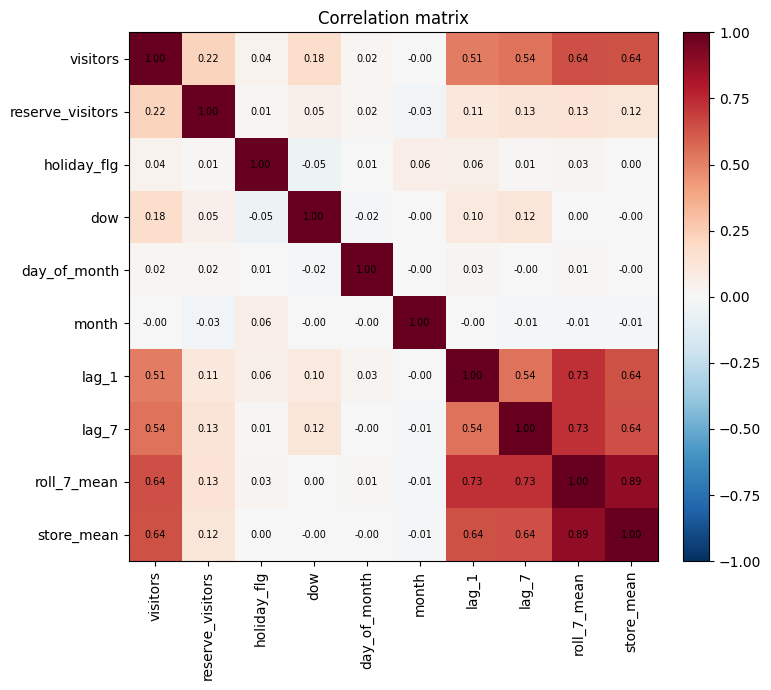

In [ ]:
# Build a numeric panel. Lags are computed per store on observed days (a preview of Phase 2).
cp = panel.merge(dates.rename(columns={"calendar_date": "visit_date"}), on="visit_date", how="left")
cp = cp.sort_values(["air_store_id", "visit_date"])
cp["dow"] = cp["visit_date"].dt.dayofweek
cp["day_of_month"] = cp["visit_date"].dt.day          # payday proxy (11th-place trick)
cp["month"] = cp["visit_date"].dt.month
cp["lag_1"] = cp.groupby("air_store_id")["visitors"].shift(1)
cp["lag_7"] = cp.groupby("air_store_id")["visitors"].shift(7)
cp["roll_7_mean"] = cp.groupby("air_store_id")["visitors"].transform(
    lambda s: s.shift(1).rolling(7).mean()
)
cp["store_mean"] = cp.groupby("air_store_id")["visitors"].transform("mean")

num_cols = ["visitors", "reserve_visitors", "holiday_flg", "dow", "day_of_month",
            "month", "lag_1", "lag_7", "roll_7_mean", "store_mean"]
corr = cp[num_cols].corr()
print("Correlation with target (visitors), sorted:")
print(corr["visitors"].drop("visitors").sort_values(ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

## 9. Findings & decisions

Real numbers from the executed run (252,108 visit rows, 829 AIR stores, 2016-01-01 → 2017-04-22):

- **Files:** 8 CSVs = AIR (POS, ground truth) + HPG (reservations) split + an id-relation join
  + a shared calendar. Only `air_visit_data` holds the target. `hpg_reserve` is by far the
  biggest table (2.0M rows / 120MB) yet feeds only 150 AIR stores.
- **Nulls:** **none** — every one of the 8 tables is complete, and there are **0 duplicate
  (store, date)** rows. The "missing data" here is structural (absent days), not NaNs.
- **Cardinality:** **829** AIR stores, **14** genres, **103** areas. Only **150** AIR stores
  appear in `store_id_relation`, so HPG reservation features cover ~18% of stores and must
  default to 0 elsewhere.
- **Target:** right-skewed counts (mean 21.0, median 17, max 877, **skew 3.31**); after `log1p`
  **skew → -0.45** (near-symmetric). Confirms the `log1p` target + RMSLE choice.
- **Missing days:** per-store coverage averages **0.85** (median 0.86, min 0.14) — **44,171**
  closed day-rows are absent across stores' active spans. **Decision:** reindex each store to a
  full daily calendar over its active span, keep the target observed + an `is_closed` flag
  (don't inject fake zeros), so lags/rollings are calendar-aligned. (Winners filled `0` instead
  — we keep that as a Phase-7 A/B.)
- **Seasonality:** holidays lift mean demand **20.8 → 23.7**; strong day-of-week effect; the
  holdout window (2017-04-23–2017-05-31, **39 days, 4 flagged holidays**) is Golden Week →
  validation must stratify holiday vs normal days.
- **Reservations:** present on **14.2%** of visit-days; where present, **corr 0.416** with actual
  visitors. Real but partial signal → keep as a feature, default 0 when absent.
- **Correlation with target (the feature shortlist works):** `roll_7_mean` **0.64**, `store_mean`
  **0.64**, `lag_7` **0.54**, `lag_1` **0.51**, `reserve_visitors` **0.22**, `dow` **0.18**. The
  rolling/lag/store-aggregate family carries the signal — exactly what the top Kaggle solutions
  leaned on (below).

## Feature-engineering ideas (from top Kaggle solutions)

What the leading public solutions for this exact dataset did — our Phase 2 menu:

- **Rolling means on visitors** (the highest-value features): window **means** over 7/14/28/35
  days (+ optional median, robust to spikes), always shifted ≥1 day. Strong public solutions
  used **means / exponentially-weighted means** — *not* std/min/max (verified in
  [dkivaranovic's solution](https://github.com/dkivaranovic/kaggledays-recruit)); std/min/max
  is deferred to possible improvements.
- **Lag features:** visitors at t−1, t−7, t−14, … (same weekday matters most).
- **Calendar features:** day-of-week, is-weekend, holiday_flg, **day-before/after a holiday**,
  month, and **day-of-month as a payday proxy** (an 11th-place trick).
- **Per-store / per-(store, dow) aggregates:** mean/median visitors by store and by
  store×weekday — cheap, strong priors that also help cold-start stores via genre/area means.
- **Reservation features:** same-day reserved visitors, count of reservations, and **lead time**
  (reserve_datetime → visit_datetime); sum AIR + HPG.
- **Closed-day handling:** winners **resampled to a daily index filling 0** so time-based
  rolling windows stay calendar-aligned — the main reason to revisit our absent-row policy.
- **External weather, KMeans location clustering, std/min/max rolling, outlier capping:**
  all **deferred to possible improvements** — see `../docs/02-features.md`.

Sources:
[Max Halford — 8th place](https://github.com/MaxHalford/kaggle-recruit-restaurant) ·
[XIUQI1994 — 11th place](https://github.com/XIUQI1994/Kaggle_Recruit-Restaurant-Visitor-Forecasting_) ·
[Learnings from Kaggle's Forecasting Competitions (arXiv 2009.07701)](https://arxiv.org/pdf/2009.07701) ·
[Competition page](https://www.kaggle.com/c/recruit-restaurant-visitor-forecasting)

**The locked v1 set + the deferred "possible improvements" list live in [`../docs/02-features.md`](../docs/02-features.md).**


## 10. Build the v1 feature set (Phase 2)

Loads the data **through the `DataSource` port** (`RecruitCsvSource`) — which hides the
AIR/HPG split and normalises onto `store_id / date / visitors` — then runs the pure
`build_features` pipeline. This is the same path the use cases use; no notebook-only glue.
See [`../docs/01-data.md`](../docs/01-data.md) and [`../docs/02-features.md`](../docs/02-features.md).

In [ ]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from forecasting.adapters.data.recruit_csv import RecruitCsvSource
from forecasting.domain.features import build_features

# Canonical load through the port (AIR + HPG joined, reservations + lead time computed).
raw = RecruitCsvSource(DATA).load()
feat = build_features(
    raw.visits, reservations=raw.reservations, stores=raw.stores, holidays=raw.holidays
)
print("feature matrix:", feat.shape)
print("columns:", list(feat.columns))
feat.head()


feature matrix: (296279, 38)
columns: ['store_id', 'date', 'visitors', 'is_closed', 'dow', 'is_weekend', 'month', 'day_of_month', 'doy_sin', 'doy_cos', 'is_holiday', 'day_before_holiday', 'day_after_holiday', 'golden_week', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35', 'roll_mean_7', 'roll_median_7', 'roll_mean_14', 'roll_median_14', 'roll_mean_28', 'roll_median_28', 'roll_mean_35', 'roll_median_35', 'reserve_visitors', 'reserve_count', 'reserve_lead_time_mean', 'store_mean', 'store_median', 'store_dow_mean', 'store_dow_median', 'genre', 'area_prefecture', 'area_ward']


,store_id,date,visitors,is_closed,dow,is_weekend,month,day_of_month,doy_sin,doy_cos,is_holiday,day_before_holiday,day_after_holiday,golden_week,lag_1,lag_7,lag_14,lag_21,lag_28,lag_35,roll_mean_7,roll_median_7,roll_mean_14,roll_median_14,roll_mean_28,roll_median_28,roll_mean_35,roll_median_35,reserve_visitors,reserve_count,reserve_lead_time_mean,store_mean,store_median,store_dow_mean,store_dow_median,genre,area_prefecture,area_ward
0,air_00a91d42b08b08d9,2016-07-01,35.0,0,4,0,7,1,-0.006451,-0.999979,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,1.208333,20.442568,20.0,33.953488,35.0,Italian/French,Tōkyō-to,Chiyoda-ku
1,air_00a91d42b08b08d9,2016-07-02,9.0,0,5,1,7,2,-0.023651,-0.999720,0,0,0,0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0.000000,20.442568,20.0,13.232558,9.0,Italian/French,Tōkyō-to,Chiyoda-ku
2,air_00a91d42b08b08d9,2016-07-03,0.0,1,6,1,7,3,-0.040844,-0.999166,0,0,0,0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0.000000,20.442568,20.0,0.047619,0.0,Italian/French,Tōkyō-to,Chiyoda-ku
3,air_00a91d42b08b08d9,2016-07-04,20.0,0,0,0,7,4,-0.058026,-0.998315,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0.000000,20.442568,20.0,18.714286,18.0,Italian/French,Tōkyō-to,Chiyoda-ku
4,air_00a91d42b08b08d9,2016-07-05,25.0,0,1,0,7,5,-0.075190,-0.997169,0,0,0,0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0.000000,20.442568,20.0,23.190476,24.0,Italian/French,Tōkyō-to,Chiyoda-ku


In [ ]:
print("rows after closed-day reindex:", len(feat), " (raw visits:", len(visits), ")")
print("\nnull counts (lag/rolling NaNs at each store's series start are expected):")
print(feat.isna().sum()[lambda s: s > 0].sort_values(ascending=False).to_string())

# Sanity: engineered features should correlate with the target.
num = feat.select_dtypes("number")
print("\ntop |corr| with visitors:")
print(num.corr()["visitors"].drop("visitors").abs().sort_values(ascending=False).head(12).round(3).to_string())


rows after closed-day reindex: 296279  (raw visits: 252108 )

null counts (lag/rolling NaNs at each store's series start are expected):
lag_35            29015
roll_mean_35      29015
roll_median_35    29015
lag_28            23212
roll_mean_28      23212
roll_median_28    23212
lag_21            17409
lag_14            11606
roll_mean_14      11606
roll_median_14    11606
lag_7              5803
roll_mean_7        5803
roll_median_7      5803
lag_1               829

top |corr| with visitors:


store_dow_mean      0.741
store_dow_median    0.726
lag_7               0.614
lag_14              0.595
roll_mean_14        0.591
roll_mean_28        0.590
roll_mean_35        0.589
lag_21              0.587
lag_28              0.582
roll_mean_7         0.582
lag_35              0.577
store_mean          0.568
